<a href="https://colab.research.google.com/github/Mr-Zainulabadin/python_programing/blob/main/GA_Wrapper_Feature_Selection_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Genetic Algorithm Wrapper Feature Selection for Pima Diabetes Dataset

This notebook implements:

- Genetic Algorithm Wrapper Feature Selection
- Gaussian Naive Bayes as Fitness Function
- Chromosome Representation
- Crossover and Mutation
- Fitness Evolution Graph
- Accuracy Comparison Graphs
- Decision Tree
- Random Forest
- Naive Bayes

Based on the GA-BN feature selection paper and modified for the Pima Diabetes dataset.


In [1]:

# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


In [2]:

# ============================================
# LOAD DATASET
# ============================================

# Replace with your dataset path
df = pd.read_csv("/content/diabetes.csv")

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# PREPROCESSING

In [3]:



# Replace invalid 0 values with NaN

cols = ['Glucose', 'BloodPressure',
        'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

# Fill missing values using median

imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])

# Features and Target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

feature_names = X.columns.tolist() #converts feature column names into a Python list

print("Features:")
print(feature_names)


Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']



# Genetic Algorithm Wrapper Feature Selection


In [4]:

# GA PARAMETERS

POP_SIZE = 20
NUM_GENERATIONS = 20
MUTATION_RATE = 0.033
CROSSOVER_RATE = 0.6

num_features = X.shape[1]


# FITNESS FUNCTION

In [81]:




def fitness_function(chromosome):

    num_selected = sum(chromosome)

    # Select only 3 to 5 features

    if num_selected < 3 or num_selected > 5:
        return 0

    # ----------------------------------------
    # Get selected feature names
    # ----------------------------------------

    selected_features = [

        feature_names[i]

        for i in range(num_features)

        if chromosome[i] == 1
    ]
    # Create feature subset

    X_selected = X[selected_features]

    # ----------------------------------------
    # Gaussian Naive Bayes
    # Used as fitness evaluator

    model = GaussianNB()

    # ----------------------------------------
    # 10-Fold Cross Validation
    # ----------------------------------------

    scores = cross_val_score(

        model,

        X_selected,

        y,

        cv=10,

        scoring='accuracy'
    )

    # ----------------------------------------
    # Return mean accuracy
    # ----------------------------------------

    return scores.mean()

# INITIAL POPULATION

In [82]:

population = []

for _ in range(POP_SIZE):

    chromosome = np.random.randint(  #randomly select and remove features
        0,
        2,
        num_features
    ).tolist()

    population.append(chromosome)

print("Initial Chromosomes:")

for i, chromosome in enumerate(population[:10]):
    print(f"Chromosome {i+1}: {chromosome}")


Initial Chromosomes:
Chromosome 1: [0, 0, 1, 1, 1, 1, 0, 1]
Chromosome 2: [1, 1, 0, 0, 0, 0, 1, 0]
Chromosome 3: [1, 0, 0, 0, 0, 0, 0, 0]
Chromosome 4: [1, 0, 0, 1, 1, 0, 1, 0]
Chromosome 5: [1, 0, 0, 1, 1, 0, 1, 1]
Chromosome 6: [0, 0, 1, 0, 1, 1, 1, 0]
Chromosome 7: [1, 1, 1, 1, 0, 0, 1, 1]
Chromosome 8: [1, 1, 1, 1, 1, 0, 1, 1]
Chromosome 9: [0, 1, 0, 1, 1, 0, 1, 1]
Chromosome 10: [0, 0, 1, 1, 1, 0, 0, 1]


# SELECTION FUNCTION

In [83]:

def selection(population, fitness_scores):

    total_fitness = sum(fitness_scores)

    probabilities = [
        fitness / total_fitness
        for fitness in fitness_scores
    ]

    selected_index = np.random.choice(
        range(len(population)),
        p=probabilities
    )

    return population[selected_index]


# CROSSOVER FUNCTION

In [84]:

def crossover(parent1, parent2):

    if random.random() < CROSSOVER_RATE:

        point1 = random.randint(1, num_features - 2)
        point2 = random.randint(point1, num_features - 1)

        child1 = (
            parent1[:point1]
            + parent2[point1:point2]
            + parent1[point2:]
        )

        child2 = (
            parent2[:point1]
            + parent1[point1:point2]
            + parent2[point2:]
        )

        return child1, child2

    return parent1, parent2


In [99]:
print(CROSSOVER_RATE)
print(parent1)
print(parent2)
print(child1)
print(child2)


0.6
[0, 1, 0, 1, 1, 0, 1, 1]
[0, 1, 1, 0, 1, 0, 1, 1]
[0, 1, 0, 0, 1, 0, 1, 1]
[0, 1, 1, 1, 1, 0, 1, 1]


# MUTATION FUNCTION

In [85]:


def mutation(chromosome):

    for i in range(num_features):

        if random.random() < MUTATION_RATE:

            chromosome[i] = 1 - chromosome[i]

    return chromosome


In [86]:

# MAIN GA LOOP


best_chromosome = None
best_score = 0

generation_scores = []

for generation in range(NUM_GENERATIONS):

    fitness_scores = [
        fitness_function(chromosome)
        for chromosome in population
    ]

    max_index = np.argmax(fitness_scores)

    best_generation_chromosome = population[max_index]

    if fitness_scores[max_index] > best_score:

        best_score = fitness_scores[max_index]
        best_chromosome = best_generation_chromosome

    generation_scores.append(best_score)

    print("=" * 50)
    print(f"Generation: {generation + 1}")
    print(f"Best Chromosome: {best_generation_chromosome}")
    print(f"Best Accuracy: {best_score:.4f}")

    new_population = []

    while len(new_population) < POP_SIZE:

        parent1 = selection(population, fitness_scores)
        parent2 = selection(population, fitness_scores)

        child1, child2 = crossover(parent1, parent2)

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)
        new_population.append(child2)

    population = new_population[:POP_SIZE]  #Replaces old population with new generation.


Generation: 1
Best Chromosome: [1, 1, 0, 0, 0, 0, 1, 0]
Best Accuracy: 0.7513
Generation: 2
Best Chromosome: [1, 1, 0, 0, 0, 0, 1, 0]
Best Accuracy: 0.7513
Generation: 3
Best Chromosome: [1, 1, 0, 0, 1, 0, 1, 0]
Best Accuracy: 0.7552
Generation: 4
Best Chromosome: [0, 1, 0, 0, 0, 1, 1, 0]
Best Accuracy: 0.7669
Generation: 5
Best Chromosome: [1, 1, 0, 0, 1, 1, 1, 0]
Best Accuracy: 0.7682
Generation: 6
Best Chromosome: [0, 1, 0, 0, 0, 1, 1, 1]
Best Accuracy: 0.7787
Generation: 7
Best Chromosome: [0, 1, 0, 0, 0, 1, 1, 1]
Best Accuracy: 0.7787
Generation: 8
Best Chromosome: [0, 1, 0, 0, 0, 1, 1, 1]
Best Accuracy: 0.7787
Generation: 9
Best Chromosome: [0, 1, 0, 0, 0, 1, 1, 1]
Best Accuracy: 0.7787
Generation: 10
Best Chromosome: [0, 1, 0, 0, 0, 1, 1, 1]
Best Accuracy: 0.7787
Generation: 11
Best Chromosome: [0, 1, 0, 1, 0, 1, 1, 1]
Best Accuracy: 0.7787
Generation: 12
Best Chromosome: [0, 1, 0, 0, 1, 1, 0, 1]
Best Accuracy: 0.7787
Generation: 13
Best Chromosome: [0, 1, 0, 0, 1, 1, 0, 1]
Best

In [87]:

# FINAL SELECTED FEATURES


selected_features = [
    feature_names[i]
    for i in range(num_features)
    if best_chromosome[i] == 1
]

print("Selected Features:")
print(selected_features)

print("\nBest Chromosome:")
print(best_chromosome)

print(f"\nBest Accuracy: {best_score:.4f}")


Selected Features:
['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Best Chromosome:
[0, 1, 1, 0, 0, 1, 1, 1]

Best Accuracy: 0.7787



# Chromosome Visualization


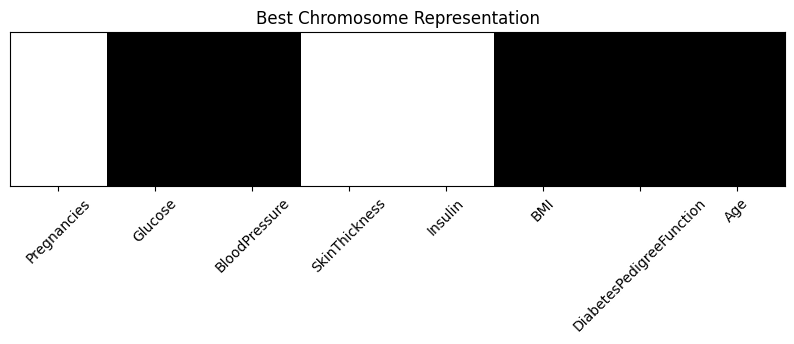

In [88]:

# ============================================
# CHROMOSOME VISUALIZATION
# ============================================

plt.figure(figsize=(10,2))

plt.imshow(
    [best_chromosome],
    cmap='binary',
    aspect='auto'
)

plt.xticks(
    range(num_features),
    feature_names,
    rotation=45
)

plt.yticks([])

plt.title("Best Chromosome Representation")

plt.show()



# Fitness Evolution Graph


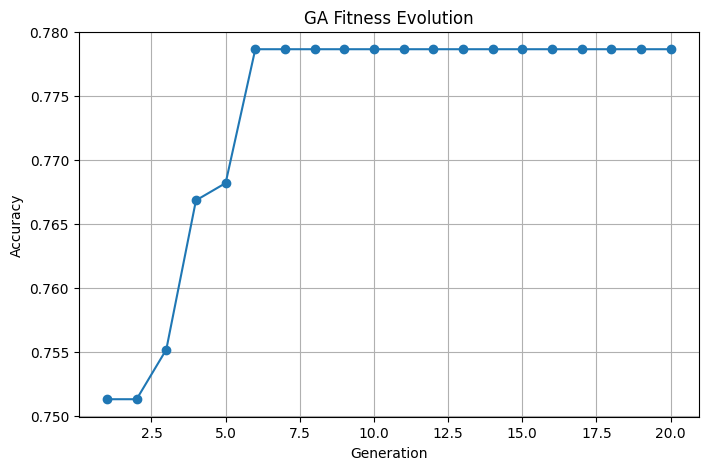

In [89]:

# ============================================
# FITNESS EVOLUTION
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, NUM_GENERATIONS + 1),
    generation_scores,
    marker='o'
)

plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("GA Fitness Evolution")

plt.grid(True)

plt.show()



# Machine Learning Models


In [90]:

# ============================================
# FINAL DATASET
# ============================================

X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.3,
    random_state=42
)


# DECISION TREE

In [91]:


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("=" * 50)
print("Decision Tree")
print("=" * 50)

print(f"Accuracy: {dt_accuracy:.4f}")

print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy: 0.7013
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       151
           1       0.56      0.62      0.59        80

    accuracy                           0.70       231
   macro avg       0.68      0.68      0.68       231
weighted avg       0.71      0.70      0.70       231



In [92]:
# ============================================
# RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("=" * 50)
print("Random Forest")
print("=" * 50)

print(f"Accuracy: {rf_accuracy:.4f}")

print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.7489
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231



In [94]:
# ============================================
# NAIVE BAYES
# ============================================

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("=" * 50)
print("Naive Bayes")
print("=" * 50)

print(f"Accuracy: {nb_accuracy:.4f}")

print(classification_report(y_test, nb_pred))

Naive Bayes
Accuracy: 0.7359
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       151
           1       0.62      0.60      0.61        80

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.71       231
weighted avg       0.73      0.74      0.73       231




# Accuracy Comparison Graph


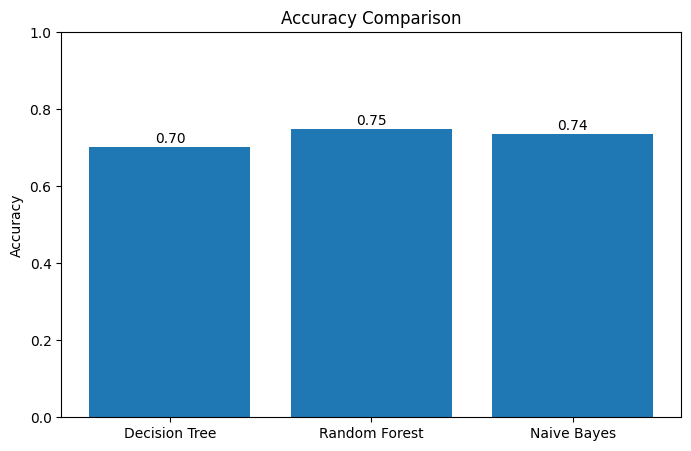

In [95]:
# ============================================
# ACCURACY COMPARISON GRAPH
# ============================================

import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "Random Forest",
    "Naive Bayes"
]

accuracies = [
    dt_accuracy,
    rf_accuracy,
    nb_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.ylim(0,1)

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 0.01,
        f"{value:.2f}",
        ha='center'
    )

plt.show()